# Scenario reduction with optimal transport — zero training

A risk or pricing engine rarely gets to keep all of its Monte Carlo paths. Nested
simulation (CVA/XVA), stress-testing a book against thousands of market states, or
re-pricing an exotics portfolio overnight all need the *distribution* of simulated
paths compressed first: **take 10,000 paths, return 100 weighted scenarios** such
that any number computed on the 100 — mean, quantiles, CVaR — matches the full set.

Picking those scenarios and their probabilities *is* an optimal transport problem:
choose the small distribution closest to the empirical one under a Wasserstein-type
metric. That is exactly the classical scenario-reduction literature (Dupačová,
Gröwe-Kuska & Römisch 2003; Heitsch & Römisch 2003). This notebook solves it with
`otgan.finance.reduce.sinkhorn_reduce`, an entropic "Sinkhorn k-means" that **reuses
the same log-domain Sinkhorn solver that trains the OT-GAN** (`otgan.sinkhorn.sinkhorn`)
— the point of the repo's finance track: *the same OT engine, from images to markets*.

No neural network is trained anywhere in this notebook; it runs in about two minutes
on a laptop CPU.

## 1. Setup

All logic lives in the tested `otgan` package; the notebook only drives it. Every
random draw below takes an explicit seed, and the run is CPU-only and deterministic.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown

from otgan.device import seed_everything
from otgan.finance.reduce import (
    holdout_split,
    kmeans_reduce,
    random_subsample,
    reduction_report,
    sinkhorn_reduce,
)
from otgan.finance.simulate import gbm_paths, heston_paths, prices_from_returns

REPO = Path.cwd().resolve()
if not (REPO / "configs").exists():  # executed from examples/
    REPO = REPO.parent
FIG_DIR = REPO / "assets" / "finance"
FIG_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(11)

## 2. A 20,000-path book: GBM + Heston

Two desks' worth of simulated risk over 64 trading days (about one quarter):

- **10,000 GBM paths** — lognormal, *iid* Gaussian log-returns (μ = 5%, σ = 20%
  annualized): the well-behaved control;
- **10,000 Heston paths** — stochastic variance with κ = 2, θ = 0.04 (20% long-run
  vol), ξ = 0.3 and ρ = −0.7, so volatility clusters and crashes drag variance up
  with them (full-truncation Euler scheme).

Pooled, they form a book whose terminal distribution no single parametric family
fits. The pooled set is split **even/odd by index**: reductions are fitted on the
even half and *all* risk numbers below are reported against the held-out odd half,
so the comparison measures generalization, not in-sample memorization of the fit
paths.

In [2]:
SEQ_LEN, DT = 64, 1.0 / 252.0  # daily steps, ~ one quarter

gbm = gbm_paths(10_000, SEQ_LEN, mu=0.05, sigma=0.20, dt=DT, seed=11)
heston = heston_paths(
    10_000, SEQ_LEN, mu=0.05, dt=DT, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7, seed=12
)
book = torch.cat([gbm, heston])  # (20000, 64) log-return paths
fit_half, held_out = holdout_split(book)  # even indices -> fit, odd -> evaluation
print(f"book {tuple(book.shape)} -> fit {tuple(fit_half.shape)}, held out {tuple(held_out.shape)}")

book (20000, 64) -> fit (10000, 64), held out (10000, 64)


## 3. 10,000 paths → 100 weighted scenarios

`sinkhorn_reduce` alternates the entropic transport plan (solved by
`otgan.sinkhorn.sinkhorn`, the exact function that trains the image GAN) with a
barycentric centroid update and a column-mass weight update — free-support
"Sinkhorn k-means" in the spirit of Cuturi & Doucet (2014). As ε → 0 the plan
hardens to nearest-scenario assignment and the procedure recovers classical
scenario reduction: centroids become cluster means, weights become the
redistributed probabilities of Dupačová et al.

Two conventions:

- the squared-Euclidean cost matrix is divided by its mean (`C = C / C.mean()`)
  before the solver, so **ε is dimensionless** and directly comparable with the
  ε = 1.0 used on cosine costs in GAN training;
- at ε near 1 the plan is so diffuse that every barycentric centroid collapses
  toward the global mean path (we checked: the reduced std collapses to ~0). For
  *reduction*, ε is a hardness knob, so we run near the hard limit,
  ε = 0.01, where entropic smoothing still buys stable, fully vectorized
  solves but assignments are nearly hard.

In [3]:
K, EPSILON = 100, 0.01

t0 = time.time()
reduced = sinkhorn_reduce(
    fit_half, K, epsilon=EPSILON, sinkhorn_iters=150, seed=0
)
print(f"K={K} scenarios in {time.time() - t0:.0f}s")
print(f"distortion <M, C> = {reduced.distortion:.6f} (squared log-return units)")
print(
    f"weights: min {reduced.weights.min():.4f}, max {reduced.weights.max():.4f}, "
    f"sum {reduced.weights.sum():.4f}"
)

K=100 scenarios in 31s
distortion <M, C> = 0.008792 (squared log-return units)
weights: min 0.0100, max 0.0100, sum 1.0000


## 4. Fan chart: 100 scenarios standing in for 10,000 paths

Gray: 1,000 of the held-out paths, converted from log-returns to prices
(S₀ = 100). Colored: the 100 reduced scenarios, with line width and color carrying
each scenario's probability weight — this weighted set is what a desk would feed
to a pricer or a stress engine in place of the full simulation.

One honest detail: at this near-hard ε the optimizer settles on almost perfectly
balanced scenarios — every weight comes out ≈ 1/K = 1% (the entropic term mildly
prefers balanced clusters) — so the color/width encoding shows little variation
in this particular run. The chart still makes the structural point: the weighted
scenario set traces the body of the path cloud, and visibly spans less than its
extremes. That contraction is quantified in the table below.

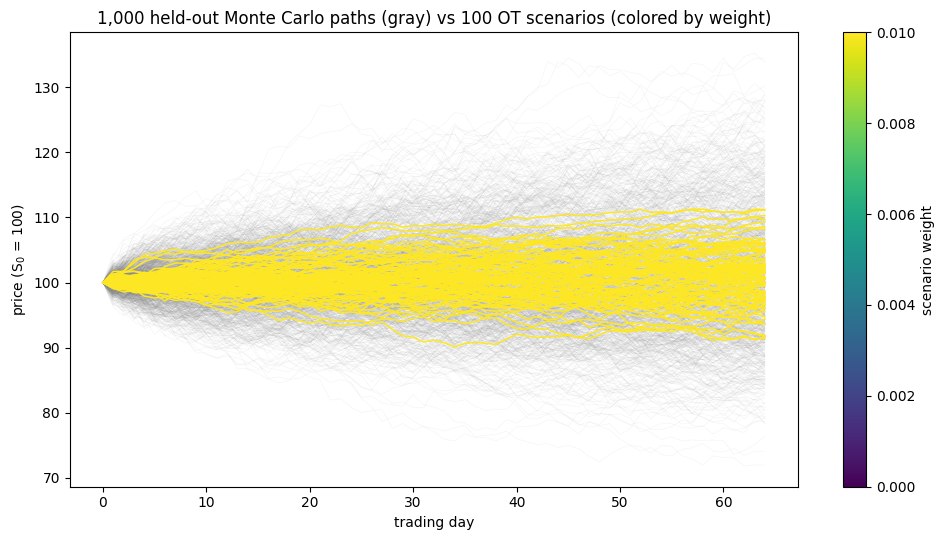

In [4]:
prices_full = prices_from_returns(held_out[:1000])
prices_scen = prices_from_returns(reduced.paths)
order = torch.argsort(reduced.weights)  # draw heavy scenarios last (on top)
weights = reduced.weights[order]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(prices_full.T.numpy(), color="0.55", lw=0.4, alpha=0.10)
norm = plt.Normalize(0.0, float(weights.max()))
cmap = plt.colormaps["viridis"]
for path, w in zip(prices_scen[order], weights, strict=True):
    ax.plot(path.numpy(), color=cmap(norm(float(w))), lw=0.5 + 60.0 * float(w))
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="scenario weight")
ax.set_xlabel("trading day")
ax.set_ylabel("price (S$_0$ = 100)")
ax.set_title("1,000 held-out Monte Carlo paths (gray) vs 100 OT scenarios (colored by weight)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fan_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Does it price? OT vs k-means vs random subsampling, out of sample

Three reductions of the same fit half, all evaluated against the **held-out**
half:

- `sinkhorn_reduce` — entropic OT, this notebook's method;
- `kmeans_reduce` — classical hard reduction (k-means++ init, Lloyd iterations,
  weights = cluster frequencies): the ε → 0 reference point;
- `random_subsample` — keep 100 random paths, weight 1/100: the baseline every
  reduction must beat.

Columns: the transport **distortion** (mean squared distance between each path
and its representative, in data units — lower is better), then statistics of the
**terminal log-return** ∑ᵤ rᵤ: mean, std, 5%/95% quantiles, and the CVaR of the
terminal loss at 95%/99% (Rockafellar & Uryasev 2000 estimator). The first row
gives the held-out full set the reduction is trying to imitate.

In [5]:
methods = {
    "sinkhorn_reduce": reduced,
    "kmeans_reduce": kmeans_reduce(fit_half, K, seed=0),
    "random_subsample": random_subsample(fit_half, K, seed=0),
}
reports = {name: reduction_report(held_out, rs, alphas=(0.05, 0.95, 0.99)) for name, rs in methods.items()}

stats = ["mean", "std", "q0.05", "q0.95", "cvar0.95", "cvar0.99"]
ref = reports["sinkhorn_reduce"]
lines = [
    "| method | distortion | " + " | ".join(stats) + " |",
    "|---|" + "---:|" * (len(stats) + 1),
    "| held-out full (N=10,000) | — | "
    + " | ".join(f"{ref[s + '_full']:+.4f}" for s in stats)
    + " |",
]
for name, rs in methods.items():
    rep = reports[name]
    lines.append(
        f"| {name} (K={K}) | {rs.distortion:.6f} | "
        + " | ".join(f"{rep[s + '_reduced']:+.4f}" for s in stats)
        + " |"
    )
table_markdown = "\n".join(lines)
(FIG_DIR / "reduction_table.md").write_text(table_markdown + "\n")
Markdown(table_markdown)

| method | distortion | mean | std | q0.05 | q0.95 | cvar0.95 | cvar0.99 |
|---|---:|---:|---:|---:|---:|---:|---:|
| held-out full (N=10,000) | — | +0.0058 | +0.1010 | -0.1658 | +0.1610 | +0.2210 | +0.3073 |
| sinkhorn_reduce (K=100) | 0.008792 | +0.0095 | +0.0428 | -0.0655 | +0.0822 | +0.0799 | +0.0884 |
| kmeans_reduce (K=100) | 0.008866 | +0.0095 | +0.0410 | -0.0592 | +0.0759 | +0.0791 | +0.1053 |
| random_subsample (K=100) | 0.012031 | +0.0013 | +0.0938 | -0.1461 | +0.1769 | +0.1628 | +0.1859 |

## 6. Reading the table — and what a desk does with it

Three observations, in decreasing order of comfort:

- **Distortion — the OT criterion — `sinkhorn_reduce` wins.** 0.00879 against
  0.00887 for k-means and 0.01203 for random subsampling. The reducer optimizes
  exactly this quantity, and beating Lloyd's algorithm while *also* returning a
  transport plan alongside the scenarios (with fixed uniform marginals the
  weights stay 1/K; non-uniform weights would need an unbalanced or
  free-marginal variant) is the value of doing the reduction with the Sinkhorn
  solver.
- **The center is accurate.** Both centroid methods land the terminal mean at
  +0.0095 against +0.0058 held out — most of that gap is fit-half vs held-out
  sampling noise, and random subsampling does no better (+0.0013).
- **The tails are honestly understated — by every centroid method.** Reduced std
  ≈ 0.043 against 0.101 held out; CVaR₉₅ ≈ 0.080 against 0.221, with k-means
  suffering identically (CVaR fidelity is a tie: OT slightly closer at 95%,
  k-means slightly closer at 99%). The barycentric average inside each cluster
  shrinks extremes — Jensen's inequality, not a solver artifact.
  `random_subsample` keeps actual paths, so its unconditional statistics are
  unbiased (std 0.094, CVaR₉₅ 0.163) — but it represents individual paths ~37%
  worse, and its deep tail rests on one or two retained paths. This is the
  classical accuracy-versus-tail-fidelity trade-off of scenario reduction.

On a desk this compression shows up wherever the inner loop is expensive:
re-pricing a structured book under every scenario, nested CVA/XVA simulation, or
a regulatory stress grid — 100 weighted scenarios in place of 10,000 paths makes
the inner loop 100× cheaper with a controlled, *measured* distributional error.

Natural next steps, deliberately out of scope here:

- **multi-asset scenario cubes** — the reducer is dimension-agnostic (it sees
  flattened paths), so correlated multi-asset books drop in unchanged;
- **importance-weighted CVaR refinement** — spend more of the K scenarios in the
  loss tail (reduce the tail and the body separately, or re-solve with a
  tail-weighted source marginal), which is how centroid-style scenario sets
  recover tail fidelity in practice.